Dataset Shape: (150, 4)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Classes:
['setosa' 'versicolor' 'virginica']

Training samples: 120
Testing samples: 30

Decision Tree Performance
-------------------------
Training Accuracy: 0.9833
Testing Accuracy : 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg

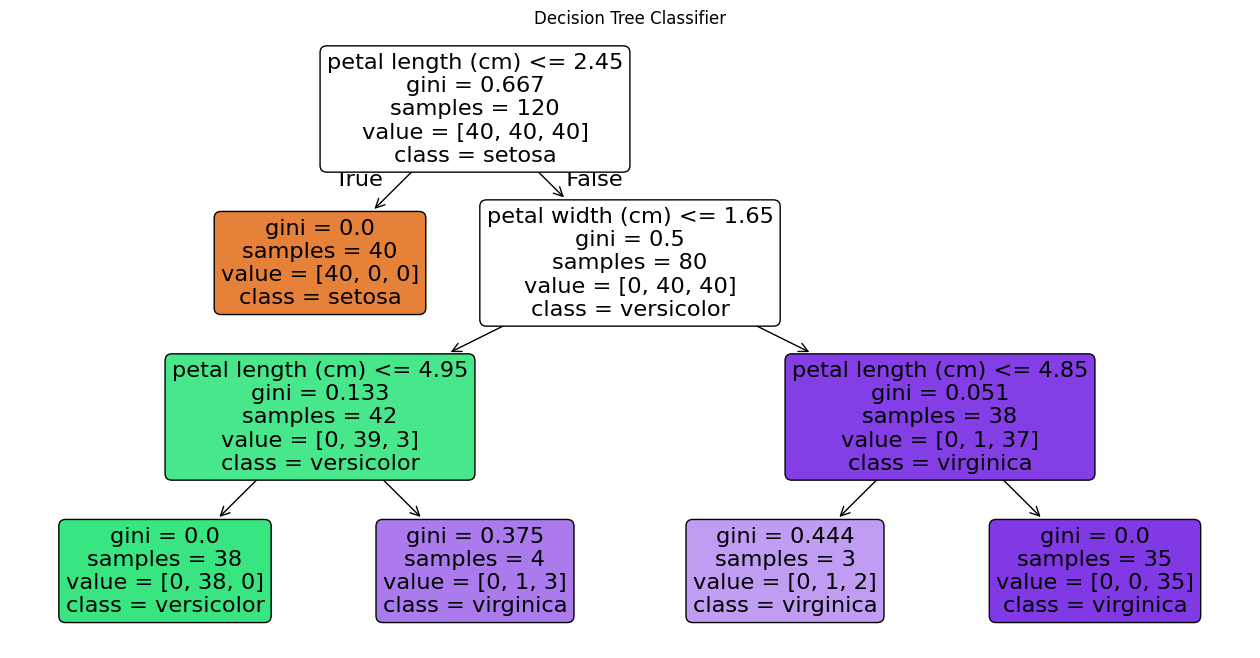


Feature Importance:
petal length (cm)    0.579077
petal width (cm)     0.420923
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


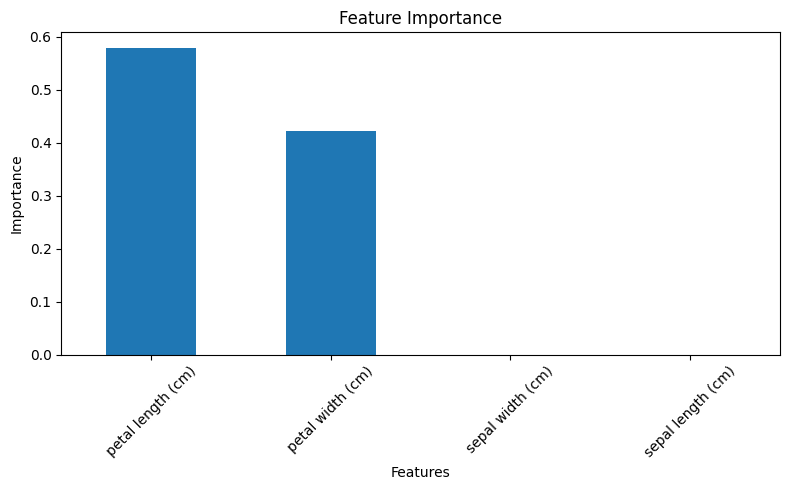


Performance Comparison:
   Max Depth  Training Accuracy  Testing Accuracy
0          1           0.666667          0.666667
1          2           0.966667          0.933333
2          3           0.983333          0.966667
3          4           0.991667          0.933333
4          5           1.000000          0.933333
5          6           1.000000          0.933333
6          7           1.000000          0.933333
7          8           1.000000          0.933333
8          9           1.000000          0.933333
9         10           1.000000          0.933333


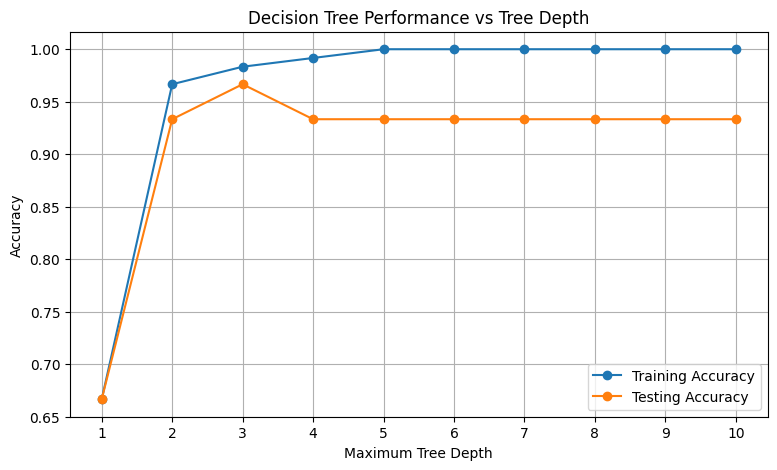

In [1]:
# TASK 28 - Decision Tree Classifier

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


# 1. Load Dataset
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget Classes:")
print(iris.target_names)


# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# 3. Train Decision Tree
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


# 4. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


# 5. Performance
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nDecision Tree Performance")
print("-------------------------")
print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=iris.target_names
))


# 6. Visualize Decision Tree
plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.show()


# 7. Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)


# 8. Feature Importance Visualization
plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 9. Compare Different Tree Depths

depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_scores.append(
        tree.score(X_train, y_train)
    )

    test_scores.append(
        tree.score(X_test, y_test)
    )


# 10. Performance Comparison
results = pd.DataFrame({
    "Max Depth": list(depths),
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores
})

print("\nPerformance Comparison:")
print(results)


# 11. Plot Training vs Testing Accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs Tree Depth")
plt.xticks(list(depths))
plt.legend()
plt.grid(True)

plt.show()